# Calls exploration

Starter scaffold for poking at the call DataFrames.

If you haven't already, run `python scripts/cache_calls_to_parquet.py` once to convert the CSVs to parquet — this notebook expects the parquet cache to exist.

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARQUET_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")

In [13]:
FIGURES_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")


In [14]:
# Shared analysis settings — change here, every plotting cell picks them up.
N = 10  # minutes per bin
LIGHT_DEFAULT = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}


## What's available?

In [2]:
sorted(p.name for p in PARQUET_DIR.glob("*.parquet"))

['all_calls_2024_12.parquet',
 'all_calls_2025_03.parquet',
 'all_calls_2025_07.parquet',
 'all_calls_2025_10.parquet',
 'all_calls_2026_02.parquet']

## Load one month

Each row is one call. To work with several months at once, load each parquet with `pd.read_parquet(...)` and concatenate them with `pd.concat([...], ignore_index=True)`.

In [11]:
df = pd.read_parquet(PARQUET_DIR / "all_calls_2025_10.parquet")
df.head()

,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,meanprob_high_freq,meanprob_newborn,meanprob_stacks,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment
0,332,0,stacks,91.660416,91.913208,0.252792,underground,30,0.024811,0.034895,0.008730,0.001708,0.849352,0.005861,91.660416,91.913208,2025-10-06 15:07:59.660416,2025-10-06 15:07:59.913208,2025_10,1
1,332,0,stacks,92.018816,92.141816,0.123000,underground,30,0.112390,0.025191,0.009005,0.001420,0.784741,0.007076,92.018816,92.141816,2025-10-06 15:08:00.018816,2025-10-06 15:08:00.141816,2025_10,1
2,332,0,stacks,93.361408,93.478392,0.116984,underground,30,0.010942,0.019514,0.007465,0.001593,0.876718,0.006235,93.361408,93.478392,2025-10-06 15:08:01.361408,2025-10-06 15:08:01.478392,2025_10,1
3,332,0,stacks,96.020992,96.129528,0.108536,underground,30,0.073119,0.025917,0.008601,0.001729,0.792288,0.008054,96.020992,96.129528,2025-10-06 15:08:04.020992,2025-10-06 15:08:04.129528,2025_10,1
4,332,0,stacks,97.794048,97.970424,0.176376,underground,30,0.065315,0.016790,0.007076,0.000701,0.808000,0.005571,97.794048,97.970424,2025-10-06 15:08:05.794048,2025-10-06 15:08:05.970424,2025_10,1


## Shape and dtypes

In [18]:
print(df.shape)
df.info()

(360957, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360957 entries, 0 to 360956
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   exp                        360957 non-null  int64         
 1   file_num                   360957 non-null  int64         
 2   event_type                 360957 non-null  object        
 3   start_time_file_sec        360957 non-null  float64       
 4   stop_time_file_sec         360957 non-null  float64       
 5   duration_sec               360957 non-null  float64       
 6   assigned_location          360957 non-null  object        
 7   channel                    360957 non-null  int64         
 8   meanprob_noise             360957 non-null  float64       
 9   meanprob_alarm             360957 non-null  float64       
 10  meanprob_high_freq         360957 non-null  float64       
 11  meanprob_newborn           360957 non-n

## A first cut: how many of each call type?

## Your turn

A few directions you might try next — pick one and we'll work through it together:

- How many calls per experiment? (`df.groupby("exp")...`)
- What's the distribution of call types within each location (`assigned_location`)?
- Calls per hour-of-day. (`df["start_time_real"].dt.hour`)
- Mean call duration per call type.
- ...

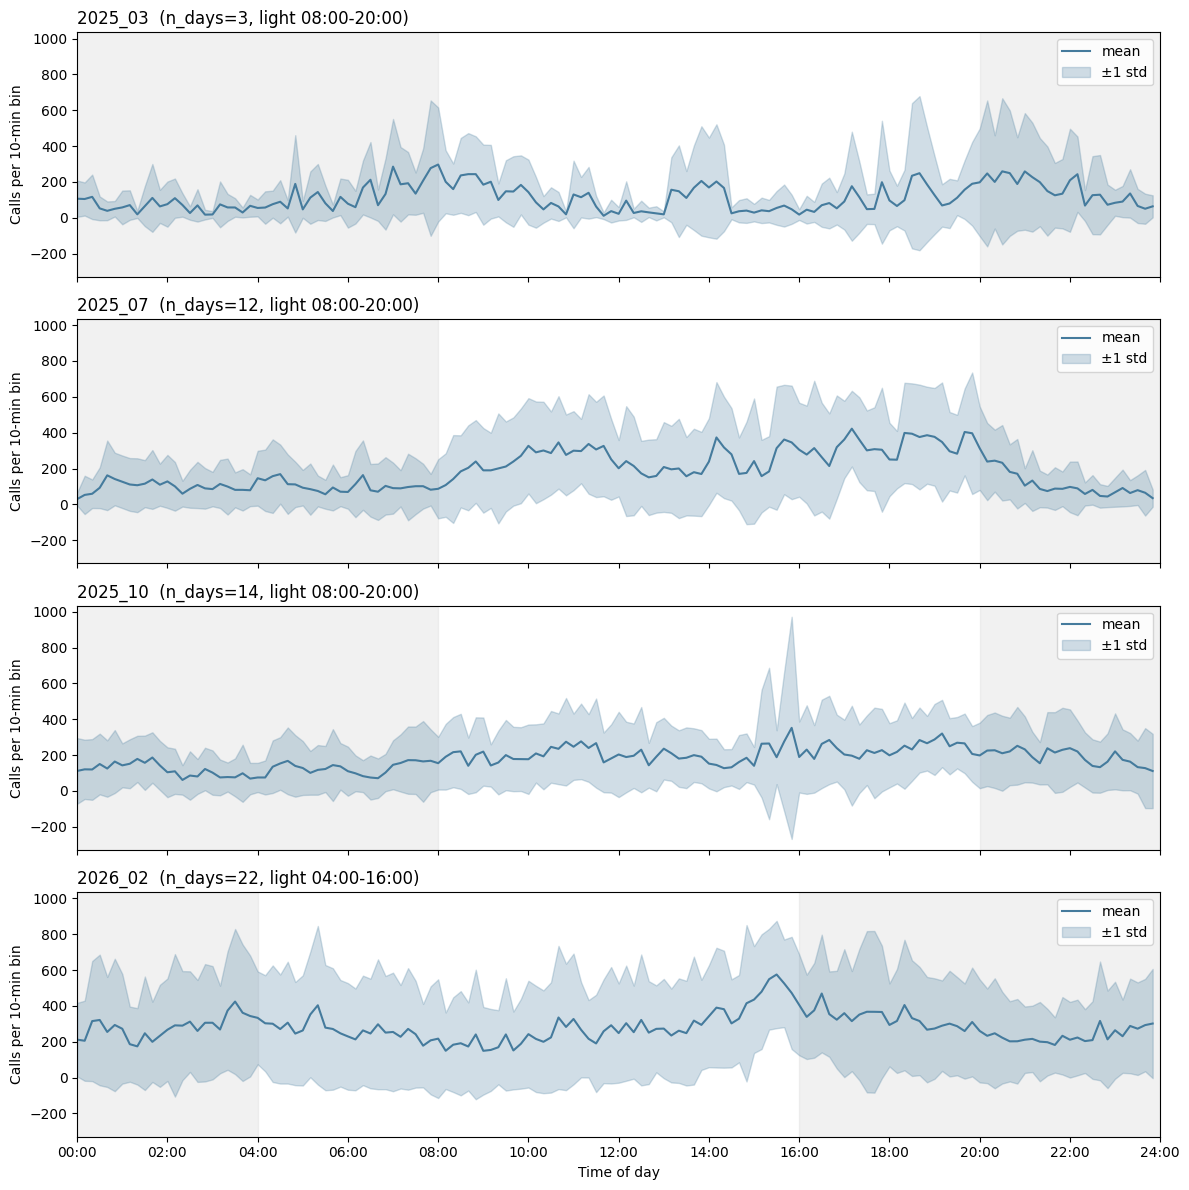

In [ ]:
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(12, 3 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day = ts.dt.normalize()
    slot = ((ts.dt.hour * 60 + ts.dt.minute) // N) * N

    counts = df_d.groupby([day, slot]).size()
    matrix = counts.unstack(fill_value=0)
    mean = matrix.mean(axis=0)
    std  = matrix.std(axis=0)

    x_hours = mean.index / 60
    ax.plot(x_hours, mean, color="#457B9D", label="mean")
    ax.fill_between(x_hours, mean - std, mean + std, alpha=0.25, color="#457B9D", label="±1 std")

    # Dark hours background — pick this date's light window, fall back to default.
    light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date_tag}  (n_days={matrix.shape[0]}, light {light_start:02d}:00-{light_end:02d}:00)", loc="left")
    ax.set_ylabel(f"Calls per {N}-min bin")
    ax.set_xlim(0, 24)
    ax.legend(loc="upper right")

# X-axis labels (only on the bottom subplot since sharex=True).
ticks = range(0, 25, 2)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Time of day")

fig.tight_layout()
plt.show()
save_fig(fig, "calls_per_bin_4dates")


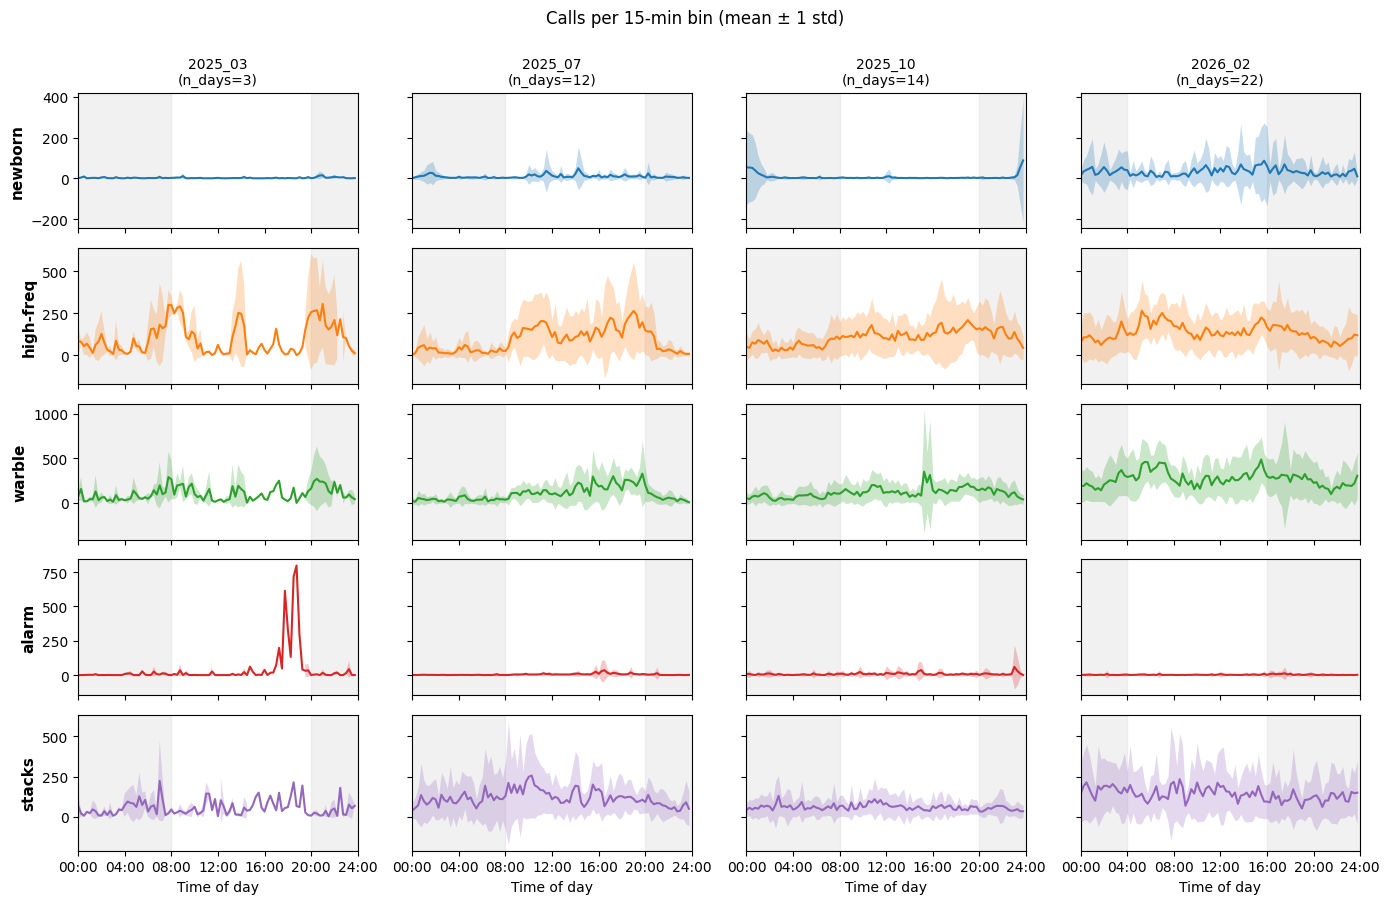

In [ ]:
# 5x4 grid: rows = call types, columns = dates.
# One curve per panel (mean ± std for that date × call-type).
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

CALL_TYPE_ORDER = ["newborn", "high-freq", "warble", "alarm", "stacks"]

# One color per call type, matching the order in the previous cell.
ct_colors = dict(zip(CALL_TYPE_ORDER, plt.rcParams["axes.prop_cycle"].by_key()["color"]))

# Pre-compute the curves so plotting stays clean.
curves = {}  # (date_tag, call_type) -> (mean Series, std Series)
n_days_by_date = {}
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day  = ts.dt.normalize().rename("day")
    slot = (((ts.dt.hour * 60 + ts.dt.minute) // N) * N).rename("slot")

    counts   = df_d.groupby([day, slot, df_d["event_type"]]).size()
    per_type = counts.unstack(level="event_type", fill_value=0)

    mean_per_type = per_type.groupby(level="slot").mean()
    std_per_type  = per_type.groupby(level="slot").std()
    n_days_by_date[date_tag] = per_type.index.get_level_values("day").nunique()

    for ct in CALL_TYPE_ORDER:
        if ct in mean_per_type.columns:
            curves[(date_tag, ct)] = (mean_per_type[ct], std_per_type[ct])

fig, axes = plt.subplots(
    len(CALL_TYPE_ORDER), len(DATES_TO_PLOT),
    figsize=(3.5 * len(DATES_TO_PLOT), 1.8 * len(CALL_TYPE_ORDER)),
    sharex=True,
    sharey="row",    # all 20 panels share one y-scale
)

for r, ct in enumerate(CALL_TYPE_ORDER):
    for c, date_tag in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        color = ct_colors[ct]

        if (date_tag, ct) in curves:
            m, s = curves[(date_tag, ct)]
            x_hours = m.index / 60
            ax.plot(x_hours, m, color=color)
            ax.fill_between(x_hours, m - s, m + s, alpha=0.25, color=color, linewidth=0)
        else:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, color="grey")

        # Dark-hours background per panel (depends on the date column).
        light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
        if light_start < light_end:
            ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
            ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
        else:
            ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

        # Top row: date title.
        if r == 0:
            ax.set_title(f"{date_tag}\n(n_days={n_days_by_date[date_tag]})", fontsize=10)
        # Leftmost column: call-type label.
        if c == 0:
            ax.set_ylabel(ct, fontsize=11, fontweight="bold")

        ax.set_xlim(0, 24)

# Bottom row: time-of-day tick labels and shared x-label.
ticks = range(0, 25, 4)
for ax in axes[-1]:
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{h:02d}:00" for h in ticks])
    ax.set_xlabel("Time of day")

fig.suptitle(f"Calls per {N}-min bin (mean ± 1 std)", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "grid_calltype_x_date")


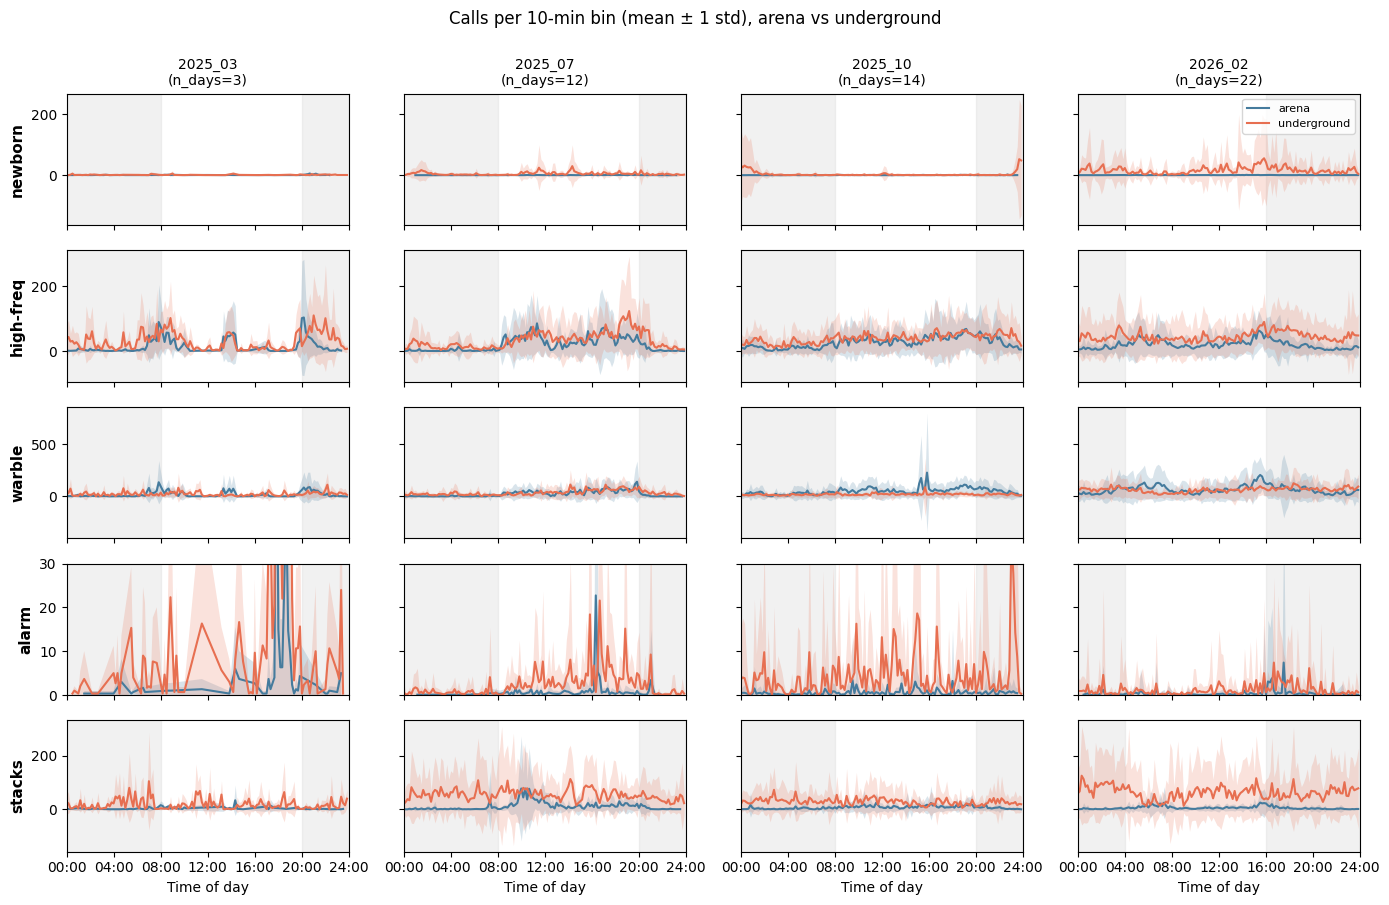

In [5]:
# 5x4 grid (call types x dates), with 2 lines per panel: arena vs underground.
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

CALL_TYPE_ORDER = ["newborn", "high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["arena", "underground"]
loc_colors = {"arena": "#457B9D", "underground": "#E76F51"}

# Pre-compute per-date mean/std as MultiIndex Series indexed by
# (slot, event_type, assigned_location).
curves = {}
n_days_by_date = {}
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day  = ts.dt.normalize().rename("day")
    slot = (((ts.dt.hour * 60 + ts.dt.minute) // N) * N).rename("slot")
    location = df_d["assigned_location"].replace({"arena_1": "arena", "arena_2": "arena"})

    # Group on FOUR keys at once. The result is a Series with a 4-level
    # MultiIndex: (day, slot, event_type, assigned_location).
    counts = df_d.groupby([day, slot, df_d["event_type"], location]).size()

    # Pivot the `day` level out to columns so we can collapse across days.
    # `fill_value=0` is critical — a missing day means zero calls there, not NaN.
    pivot = counts.unstack(level="day", fill_value=0)
    mean = pivot.mean(axis=1)   # rows: (slot, event_type, assigned_location)
    std  = pivot.std(axis=1)

    curves[date_tag] = (mean, std)
    n_days_by_date[date_tag] = pivot.shape[1]

fig, axes = plt.subplots(
    len(CALL_TYPE_ORDER), len(DATES_TO_PLOT),
    figsize=(3.5 * len(DATES_TO_PLOT), 1.8 * len(CALL_TYPE_ORDER)),
    sharex=True,
    sharey="row",   # each call-type row gets its own y-scale
)

for r, ct in enumerate(CALL_TYPE_ORDER):
    for c, date_tag in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        mean, std = curves[date_tag]

        for loc in LOCATION_ORDER:
            try:
                # .xs() pulls out a slice along given index levels, leaving the
                # other levels intact. Here we drop event_type and assigned_location,
                # leaving a Series indexed by slot — exactly what we plot.
                m_l = mean.xs((ct, loc), level=("event_type", "assigned_location"))
                s_l = std.xs((ct, loc),  level=("event_type", "assigned_location"))
            except KeyError:
                continue  # this (call_type, location) combo had no calls in this date

            x_hours = m_l.index / 60
            ax.plot(x_hours, m_l, label=loc, color=loc_colors[loc])
            ax.fill_between(x_hours, m_l - s_l, m_l + s_l,
                            alpha=0.2, color=loc_colors[loc], linewidth=0)

        # Dark-hours background.
        light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
        if light_start < light_end:
            ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
            ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
        else:
            ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

        if r == 0:
            ax.set_title(f"{date_tag}\n(n_days={n_days_by_date[date_tag]})", fontsize=10)
        if c == 0:
            ax.set_ylabel(ct, fontsize=11, fontweight="bold")
        ax.set_xlim(0, 24)

# Legend on the top-right panel only — same colors apply everywhere.
axes[0, -1].legend(loc="upper right", fontsize=8)

ticks = range(0, 25, 4)
for ax in axes[-1]:
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{h:02d}:00" for h in ticks])
    ax.set_xlabel("Time of day")

axes[3, 0].set_ylim(0, 30)   # only the "alarm" row, all 4 dates

fig.suptitle(f"Calls per {N}-min bin (mean ± 1 std), arena vs underground", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "grid_calltype_x_date_arena_vs_underground")


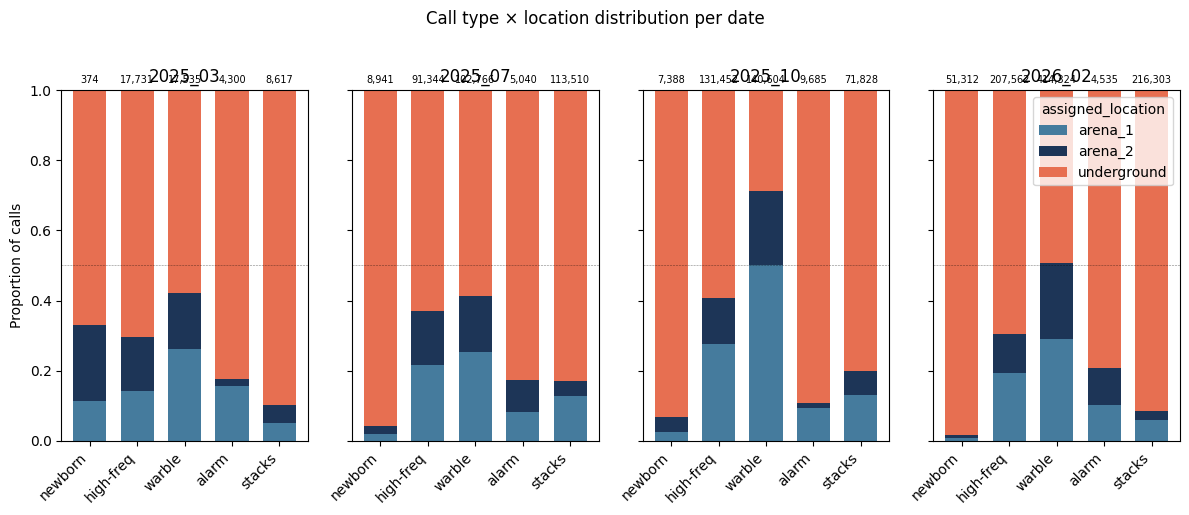

In [15]:
CALL_TYPE_ORDER = ["newborn", "high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["arena_1", "arena_2", "underground"]
LOC_COLORS      = ["#457B9D", "#1D3557", "#E76F51"]

fig, axes = plt.subplots(
    1, len(DATES_TO_PLOT),
    figsize=(3 * len(DATES_TO_PLOT), 5),
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")

    # Counts → proportions per call type.
    props = (
        df_d.groupby(["event_type", "assigned_location"])
        .size()
        .unstack(fill_value=0)
        .reindex(CALL_TYPE_ORDER, fill_value=0)
        [LOCATION_ORDER]
    )
    totals = props.sum(axis=1)
    props = props.div(totals, axis=0)

    props.plot.bar(stacked=True, ax=ax, color=LOC_COLORS, width=0.7,
                   legend=(ax is axes[-1]))

    ax.set_title(date_tag)
    ax.set_xlabel("")
    ax.set_xticklabels(CALL_TYPE_ORDER, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.4, alpha=0.5)

    # n_calls per call type as a small annotation above each bar.
    for i, n in enumerate(totals):
        ax.text(i, 1.02, f"{int(n):,}", ha="center", fontsize=7)

axes[0].set_ylabel("Proportion of calls")
fig.suptitle("Call type × location distribution per date", y=1.02, fontsize=12)
fig.tight_layout()
save_fig(fig, "call_type_location_per_date")
plt.show()


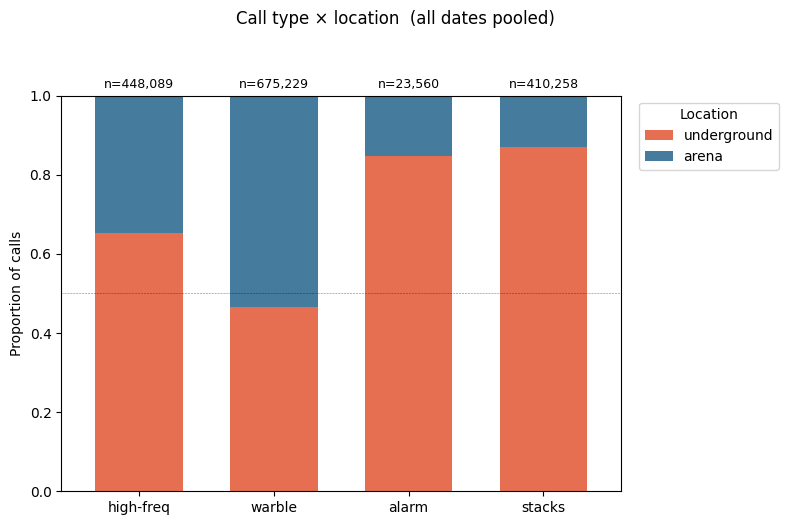

In [17]:
CALL_TYPE_ORDER = ["high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["underground", "arena"]      # underground first → goes at the bottom
LOC_COLORS      = ["#E76F51", "#457B9D"]        # match LOCATION_ORDER

df_all = pd.concat(
    [pd.read_parquet(PARQUET_DIR / f"all_calls_{d}.parquet") for d in DATES_TO_PLOT],
    ignore_index=True,
)
df_all["location"] = df_all["assigned_location"].replace(
    {"arena_1": "arena", "arena_2": "arena"}
)

props = (
    df_all.groupby(["event_type", "location"])
    .size()
    .unstack(fill_value=0)
    .reindex(CALL_TYPE_ORDER, fill_value=0)
    [LOCATION_ORDER]
)
totals = props.sum(axis=1)
props = props.div(totals, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
props.plot.bar(stacked=True, ax=ax, color=LOC_COLORS, width=0.65)

ax.set_ylabel("Proportion of calls")
ax.set_xlabel("")
ax.set_xticklabels(CALL_TYPE_ORDER, rotation=0)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

# n_calls annotations above each bar.
for i, n in enumerate(totals):
    ax.text(i, 1.02, f"n={int(n):,}", ha="center", fontsize=9)

# Title placed higher so it doesn't overlap the n= annotations.
fig.suptitle("Call type × location  (all dates pooled)", y=1.04, fontsize=12)

fig.tight_layout()
save_fig(fig, "call_type_location_pooled")
plt.show()


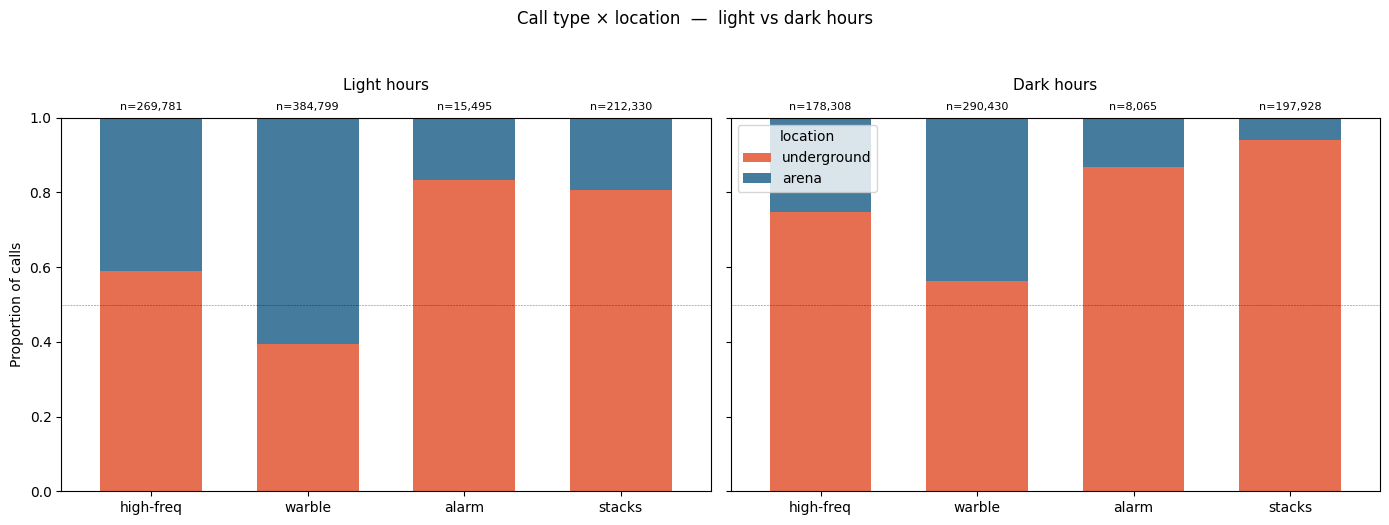

In [19]:
CALL_TYPE_ORDER = ["high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["underground", "arena"]
LOC_COLORS      = ["#E76F51", "#457B9D"]

# Pool all dates and unify arenas.
df_all = pd.concat(
    [pd.read_parquet(PARQUET_DIR / f"all_calls_{d}.parquet") for d in DATES_TO_PLOT],
    ignore_index=True,
)
df_all["location"] = df_all["assigned_location"].replace(
    {"arena_1": "arena", "arena_2": "arena"}
)

# Per-row light/dark using the per-date schedule.
ls = df_all["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0])
le = df_all["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1])
hours = df_all["start_time_real"].dt.hour
in_light = np.where(
    ls < le,
    (hours >= ls) & (hours < le),
    (hours >= ls) | (hours <  le),
)
df_all["light_dark"] = np.where(in_light, "light", "dark")

# 1×2 grid: one panel per regime.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lab in zip(axes, ["light", "dark"]):
    sub = df_all[df_all["light_dark"] == lab]

    props = (
        sub.groupby(["event_type", "location"])
        .size()
        .unstack(fill_value=0)
        .reindex(CALL_TYPE_ORDER, fill_value=0)
        [LOCATION_ORDER]
    )
    totals = props.sum(axis=1)
    props = props.div(totals, axis=0)

    props.plot.bar(stacked=True, ax=ax, color=LOC_COLORS, width=0.65,
                   legend=(ax is axes[-1]))

    ax.set_xticklabels(CALL_TYPE_ORDER, rotation=0)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.4, alpha=0.5)
    ax.set_title(f"{lab.capitalize()} hours", fontsize=11, pad=20)

    # n per call type for this regime.
    for i, n in enumerate(totals):
        ax.text(i, 1.02, f"n={int(n):,}", ha="center", fontsize=8)

axes[0].set_ylabel("Proportion of calls")
fig.suptitle("Call type × location  —  light vs dark hours", y=1.04, fontsize=12)
fig.tight_layout()
save_fig(fig, "call_type_location_light_vs_dark")
plt.show()


Total calls across all dates: 1,625,151
  underground: 1,050,709 (64.7%)
        arena:   574,442 (35.3%)


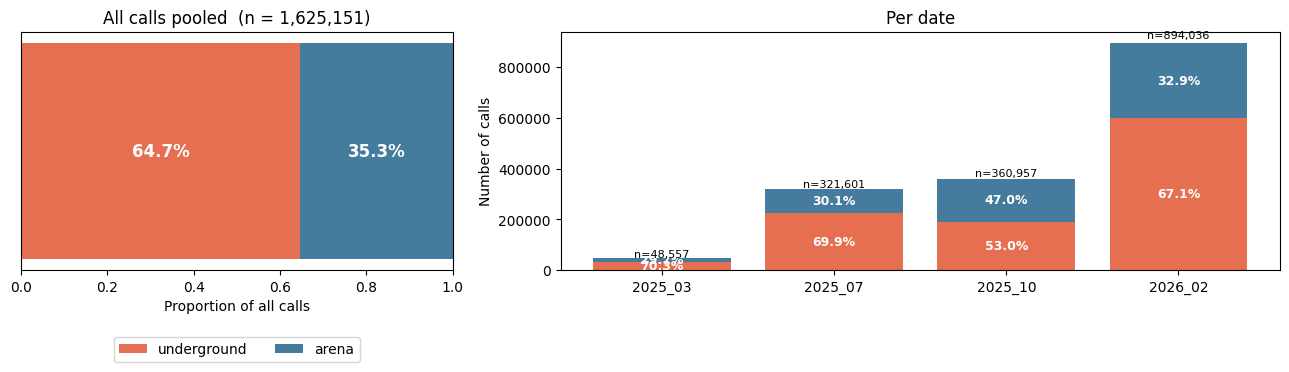

In [22]:
LOC_GROUPS = {"arena_1": "arena", "arena_2": "arena", "underground": "underground"}
LOCATION_ORDER = ["underground", "arena"]
LOC_COLORS     = ["#E76F51", "#457B9D"]

# Compute totals across all dates.
totals = {loc: 0 for loc in LOCATION_ORDER}
per_date_totals = {}

for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    df_d["location"] = df_d["assigned_location"].map(LOC_GROUPS)
    counts = df_d["location"].value_counts().reindex(LOCATION_ORDER, fill_value=0)
    per_date_totals[date_tag] = counts
    for loc in LOCATION_ORDER:
        totals[loc] += counts[loc]

n_total = sum(totals.values())
print(f"Total calls across all dates: {n_total:,}")
for loc in LOCATION_ORDER:
    print(f"  {loc:>11}: {totals[loc]:>9,} ({totals[loc]/n_total*100:.1f}%)")

# Two-panel plot: overall horizontal bar + per-date stacked bars.
fig, (ax_overall, ax_per_date) = plt.subplots(
    1, 2, figsize=(13, 4),
    gridspec_kw={"width_ratios": [1.2, 2]},
)

# (a) Overall proportion as a horizontal stacked bar.
left = 0
for loc, color in zip(LOCATION_ORDER, LOC_COLORS):
    frac = totals[loc] / n_total
    ax_overall.barh(0, frac, left=left, color=color, label=loc, height=0.5)
    ax_overall.text(left + frac / 2, 0, f"{frac*100:.1f}%",
                    ha="center", va="center", color="white",
                    fontsize=12, fontweight="bold")
    left += frac
ax_overall.set_xlim(0, 1)
ax_overall.set_yticks([])
ax_overall.set_xlabel("Proportion of all calls")
ax_overall.set_title(f"All calls pooled  (n = {n_total:,})")
ax_overall.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2)

# (b) Per-date stacked bars with proportions inside segments.
x = np.arange(len(date_labels))

ax_per_date.bar(x, under_vals, color=LOC_COLORS[0], label="underground")
ax_per_date.bar(x, arena_vals, color=LOC_COLORS[1], bottom=under_vals, label="arena")

for i, (u, a, total) in enumerate(zip(under_vals, arena_vals, date_totals)):
    if total == 0:
        continue
    # Underground proportion inside its (lower) segment.
    if u > 0:
        ax_per_date.text(i, u / 2, f"{u/total*100:.1f}%",
                         ha="center", va="center",
                         color="white", fontsize=9, fontweight="bold")
    # Arena proportion inside its (upper) segment.
    if a > 0:
        ax_per_date.text(i, u + a / 2, f"{a/total*100:.1f}%",
                         ha="center", va="center",
                         color="white", fontsize=9, fontweight="bold")
    # Total count above.
    ax_per_date.text(i, total * 1.02, f"n={total:,}",
                     ha="center", fontsize=8)

ax_per_date.set_xticks(x)
ax_per_date.set_xticklabels(date_labels, rotation=0)
ax_per_date.set_ylabel("Number of calls")
ax_per_date.set_title("Per date")

fig.tight_layout()
save_fig(fig, "calls_per_location_overall_and_per_date")
plt.show()
